# How well did the AI sort our policies into topics?

We grouped ~1.5 million policy snippets into 1,030 topic clusters (by sector: BUILDING, FOOD, ENERGY, etc.). To check whether the groups make sense, we ran an **"odd one out" test**: we showed an AI judge 5 short policy texts — 4 picked from the same cluster, 1 from a different cluster in the same sector — and asked it to point to the outsider. If the cluster is coherent, the outsider stands out. If not, the judge guesses wrong.

**Random guessing scores 20%.** Anything above that means the cluster has real content.

We did this 500 times across all 11 sectors. The charts below show how the judge did, by sector and by cluster size.

In [1]:
import json, sys
from pathlib import Path

# Find repo root.
p = Path.cwd().resolve()
while not (p / 'pyproject.toml').exists() or 'policy-analysis-workspace' not in (p / 'pyproject.toml').read_text():
    if p == p.parent: raise RuntimeError('repo root not found')
    p = p.parent
REPO = p
RUN  = REPO / 'runs/eval_v1'
if str(REPO) not in sys.path: sys.path.insert(0, str(REPO))

import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({
    'font.size': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'figure.dpi': 110,
})

summary  = json.loads((RUN / 'metrics_summary.json').read_text())
intr     = json.loads((RUN / 'metrics_intrinsic.json').read_text())
judgments = [json.loads(l) for l in (RUN / 'judgments.jsonl').read_text().splitlines() if l.strip()]
j = pd.DataFrame(judgments)
j['correct'] = (j['intruder_index'] == j['gold_intruder_index']).astype(int)
print(f'loaded {len(j)} judgments across {j["sector"].nunique()} sectors')

loaded 500 judgments across 11 sectors


## Headline

Across **500 tests**, the AI judge correctly spotted the odd policy out **73% of the time** — more than 3× random guessing.

This is a **lower bound** on real clustering quality: in our 55-item calibration, ~15% of cases the manufactured "correct answer" was actually wrong (the random outsider happened to fit better than a real cluster member), so real coherence is probably ~80%+.

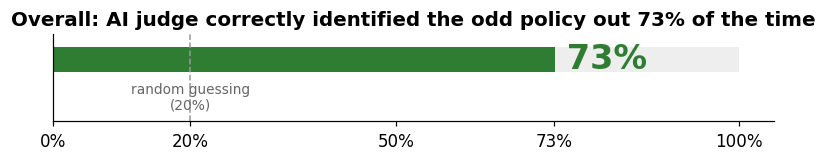

In [2]:
fig, ax = plt.subplots(figsize=(7, 1.6))
acc = summary['overall']['accuracy']
ax.barh([0], [1.0], color='#eeeeee', height=0.6)
ax.barh([0], [acc], color='#2e7d32', height=0.6)
ax.axvline(0.20, color='#999', linestyle='--', linewidth=1)
ax.text(0.20, -0.55, 'random guessing\n(20%)', ha='center', va='top', color='#666', fontsize=9)
ax.text(acc, 0, f' {acc*100:.0f}%', va='center', ha='left', fontsize=22, fontweight='bold', color='#2e7d32')
ax.set_xlim(0, 1.05); ax.set_ylim(-1.5, 0.6)
ax.set_yticks([])
ax.set_xticks([0, 0.2, 0.5, 0.73, 1.0])
ax.set_xticklabels(['0%', '20%', '50%', '73%', '100%'])
ax.set_title('Overall: AI judge correctly identified the odd policy out 73% of the time')
plt.tight_layout(); plt.show()

## Performance by sector

Some sectors cluster more cleanly than others. **INDUSTRY, SOCIAL, NATURE** scored well — the AI rarely got fooled. **MOBILITY, ENERGY, LOGISTICS** scored lower — those topic areas have messier groups and need more clustering work.

The dashed line at 20% is what you'd get from random guessing.

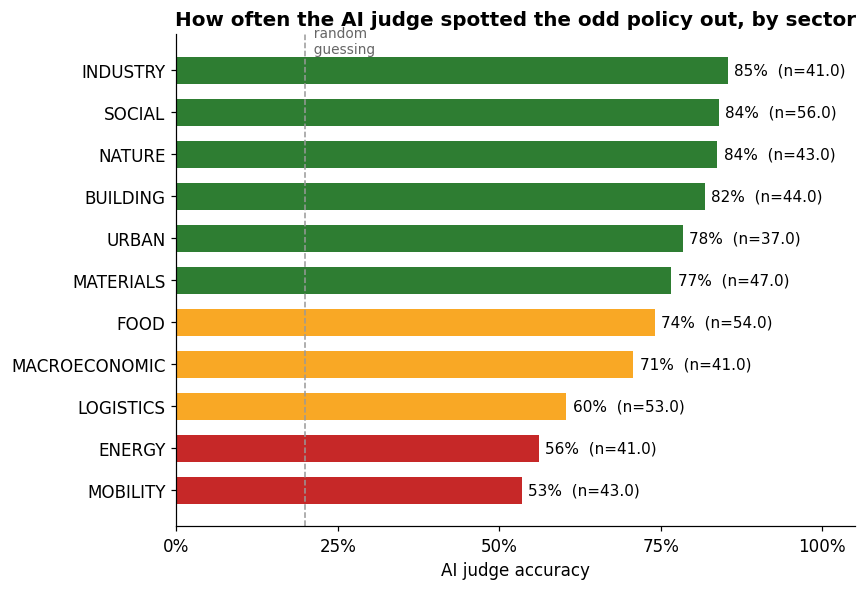

In [3]:
per_sector = (j.groupby('sector')['correct'].agg(['mean', 'count'])
              .rename(columns={'mean': 'accuracy', 'count': 'n'})
              .sort_values('accuracy', ascending=True))

fig, ax = plt.subplots(figsize=(8, 5.5))
colors = ['#c62828' if a < 0.6 else '#f9a825' if a < 0.75 else '#2e7d32' for a in per_sector['accuracy']]
bars = ax.barh(per_sector.index, per_sector['accuracy'], color=colors, height=0.65)
ax.axvline(0.20, color='#999', linestyle='--', linewidth=1)
ax.text(0.20, len(per_sector) - 0.3, '  random\n  guessing', va='center', color='#666', fontsize=9)
for sector, row in per_sector.iterrows():
    ax.text(row['accuracy'] + 0.01, sector, f"{row['accuracy']*100:.0f}%  (n={row['n']})",
            va='center', fontsize=10)
ax.set_xlim(0, 1.05)
ax.set_xticks([0, 0.25, 0.5, 0.75, 1.0])
ax.set_xticklabels(['0%', '25%', '50%', '75%', '100%'])
ax.set_title('How often the AI judge spotted the odd policy out, by sector')
ax.set_xlabel('AI judge accuracy')
plt.tight_layout(); plt.show()

## Does cluster size matter?

Yes — **bigger clusters are easier to verify** because they have more shared signal. Small clusters (≤ 50 policies) and medium ones look messier.

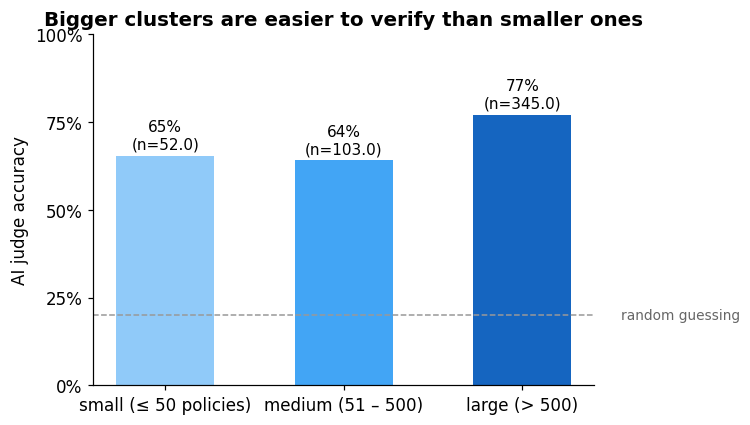

In [4]:
bucket_labels = {'small': 'small (≤ 50 policies)', 'medium': 'medium (51 – 500)', 'large': 'large (> 500)'}
buckets = (j.groupby('size_bucket')['correct'].agg(['mean', 'count'])
           .rename(columns={'mean': 'accuracy', 'count': 'n'})
           .reindex(['small', 'medium', 'large']))

fig, ax = plt.subplots(figsize=(7, 4))
colors = ['#90caf9', '#42a5f5', '#1565c0']
bars = ax.bar([bucket_labels[b] for b in buckets.index], buckets['accuracy'], color=colors, width=0.55)
ax.axhline(0.20, color='#999', linestyle='--', linewidth=1)
ax.text(2.55, 0.20, 'random guessing', va='center', color='#666', fontsize=9)
for bar, (b, row) in zip(bars, buckets.iterrows()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f"{row['accuracy']*100:.0f}%\n(n={row['n']})", ha='center', fontsize=10)
ax.set_ylim(0, 1.0)
ax.set_yticks([0, 0.25, 0.5, 0.75, 1.0])
ax.set_yticklabels(['0%', '25%', '50%', '75%', '100%'])
ax.set_title('Bigger clusters are easier to verify than smaller ones')
ax.set_ylabel('AI judge accuracy')
plt.tight_layout(); plt.show()

## How big is each sector?

Sectors differ enormously in size. **SOCIAL** alone has 111 clusters and 380k+ policies; **LOGISTICS** has 134 clusters but each one is tiny. This context matters when interpreting the accuracy chart above.

/tmp/claude-501/ipykernel_21599/2437269381.py:19: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(); plt.show()


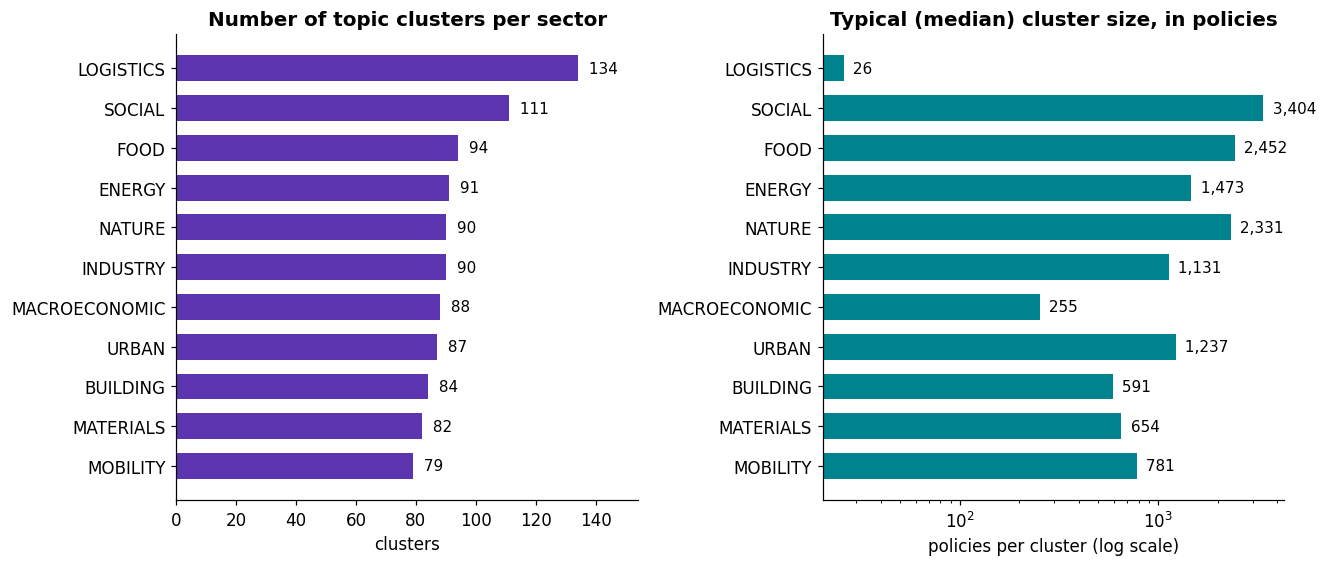

In [5]:
ps = pd.DataFrame(intr['per_sector']).T
ps['n_policies'] = ps['n_clusters'] * ps['median']  # rough; actual total per sector requires data load
ps = ps.sort_values('n_clusters', ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5), gridspec_kw={'wspace': 0.4})
axes[0].barh(ps.index, ps['n_clusters'], color='#5e35b1', height=0.65)
for s, v in ps['n_clusters'].items():
    axes[0].text(v + 2, s, f' {int(v)}', va='center', fontsize=10)
axes[0].set_title('Number of topic clusters per sector')
axes[0].set_xlabel('clusters')
axes[0].set_xlim(0, ps['n_clusters'].max() * 1.15)

axes[1].barh(ps.index, ps['median'], color='#00838f', height=0.65)
for s, v in ps['median'].items():
    axes[1].text(v * 1.05, s, f' {int(v):,}', va='center', fontsize=10)
axes[1].set_title('Typical (median) cluster size, in policies')
axes[1].set_xlabel('policies per cluster (log scale)')
axes[1].set_xscale('log')
plt.tight_layout(); plt.show()

## How sure was the AI when it answered?

The judge rates its own confidence from 1 ("unsure") to 5 ("very sure"). When it was very sure, it was right more often — a useful signal for filtering.

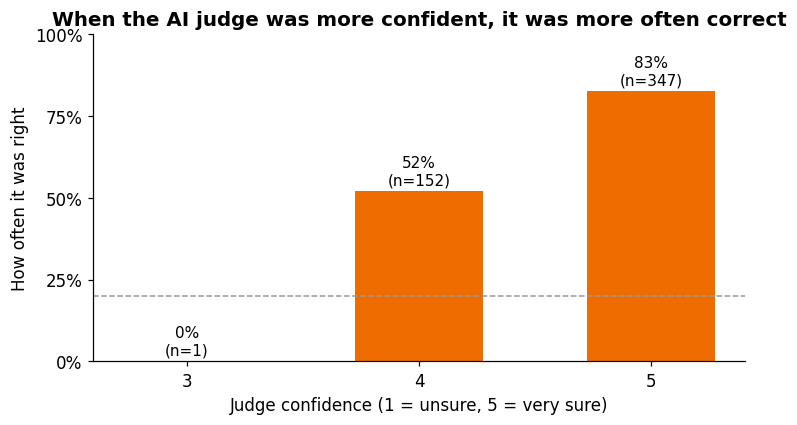

In [6]:
conf = j.groupby('confidence')['correct'].agg(['mean', 'count']).rename(columns={'mean': 'accuracy', 'count': 'n'})

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(conf.index.astype(str), conf['accuracy'], color='#ef6c00', width=0.55)
ax.axhline(0.20, color='#999', linestyle='--', linewidth=1)
for bar, (c, row) in zip(bars, conf.iterrows()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f"{row['accuracy']*100:.0f}%\n(n={int(row['n'])})", ha='center', fontsize=10)
ax.set_ylim(0, 1.0)
ax.set_yticks([0, 0.25, 0.5, 0.75, 1.0])
ax.set_yticklabels(['0%', '25%', '50%', '75%', '100%'])
ax.set_title('When the AI judge was more confident, it was more often correct')
ax.set_xlabel('Judge confidence (1 = unsure, 5 = very sure)')
ax.set_ylabel('How often it was right')
plt.tight_layout(); plt.show()

## Sanity check: did the AI judge agree with a human?

Before running on all 500 items, we ran a 55-item calibration: a human (Claude) and the AI judge (DeepSeek) each labeled the same 55 items blind. Then we compared both against the manufactured "correct answer".

**Human and AI agreed 78% of the time** — and where they disagreed with the "correct answer", they usually disagreed *together*, suggesting the manufactured answer was the wrong one, not the judge.

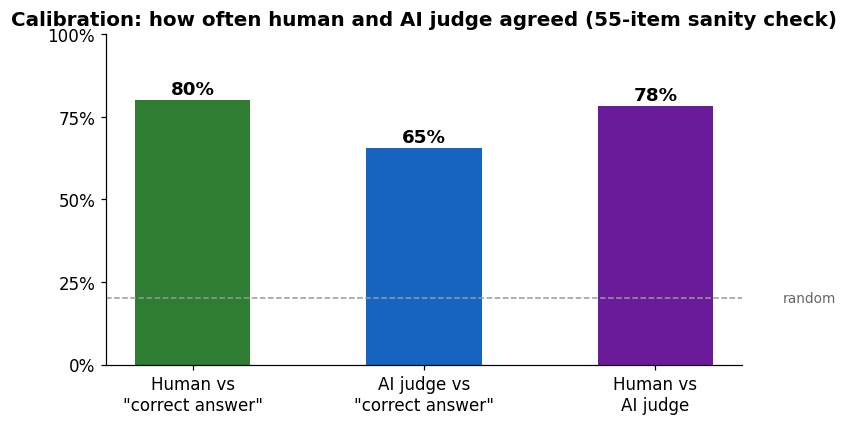

In [7]:
cal_gold   = {it['cluster_uid']: it for it in [json.loads(l) for l in (RUN/'calibration/items_gold.jsonl').read_text().splitlines()]}
cal_claude = {it['cluster_uid']: it for it in [json.loads(l) for l in (RUN/'calibration/claude_labels.jsonl').read_text().splitlines()]}
cal_deep   = {it['cluster_uid']: it for it in [json.loads(l) for l in (RUN/'calibration/judgments.jsonl').read_text().splitlines()]}
uids = sorted(set(cal_gold) & set(cal_claude) & set(cal_deep))
cd_g = sum(1 for u in uids if cal_claude[u]['intruder_index'] == cal_gold[u]['gold_intruder_index']) / len(uids)
ds_g = sum(1 for u in uids if cal_deep[u]['intruder_index'] == cal_gold[u]['gold_intruder_index']) / len(uids)
cd_ds = sum(1 for u in uids if cal_claude[u]['intruder_index'] == cal_deep[u]['intruder_index']) / len(uids)

labels = ['Human vs\n"correct answer"', 'AI judge vs\n"correct answer"', 'Human vs\nAI judge']
values = [cd_g, ds_g, cd_ds]
colors = ['#2e7d32', '#1565c0', '#6a1b9a']
fig, ax = plt.subplots(figsize=(7.5, 4))
bars = ax.bar(labels, values, color=colors, width=0.5)
ax.axhline(0.20, color='#999', linestyle='--', linewidth=1)
ax.text(2.55, 0.20, 'random', va='center', color='#666', fontsize=9)
for bar, v in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, f'{v*100:.0f}%', ha='center', fontsize=12, fontweight='bold')
ax.set_ylim(0, 1.0)
ax.set_yticks([0, 0.25, 0.5, 0.75, 1.0])
ax.set_yticklabels(['0%', '25%', '50%', '75%', '100%'])
ax.set_title('Calibration: how often human and AI judge agreed (55-item sanity check)')
plt.tight_layout(); plt.show()

## Takeaways

1. **The clusters mostly hold up.** 73% judge accuracy against a 20% random baseline means the topic groups carry real signal.
2. **Quality varies a lot by sector.** INDUSTRY, SOCIAL, and NATURE clusters are tight. MOBILITY, ENERGY, and LOGISTICS need more work.
3. **Bigger clusters are tighter.** Small clusters — fewer than 50 policies — score noticeably worse and should be reviewed by hand.
4. **The judge knows when it's guessing.** Its self-reported confidence tracks its real accuracy, so we can filter low-confidence answers out of any downstream analysis.
5. **The judge agreed with a human 78% of the time.** Where they disagreed, they usually agreed *with each other against the manufactured answer* — i.e. the test sometimes asked an unfair question, not that the judge was wrong.